In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from collections import Counter, defaultdict
from nltk.corpus import stopwords
import nltk
from wordcloud import WordCloud
import warnings
warnings.filterwarnings('ignore')
nltk.download('stopwords')
nltk.download('punkt') 
from nltk.tokenize import word_tokenize
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\MESK\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\MESK\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


# **Load IMDB Dataset**


In [ ]:
df=pd.read_csv("IMDB Dataset.csv")
df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'IMDB Dataset.csv'

In [ ]:
print(f"Dataset Shape: {df.shape}")
print(f"\nColumn names: {df.columns.tolist()}")
print(f"\nData types:\n{df.dtypes}")
print(f"\nMissing values:\n{df.isnull().sum()}")

Dataset Shape: (50000, 2)

Column names: ['review', 'sentiment']

Data types:
review       object
sentiment    object
dtype: object

Missing values:
review       0
sentiment    0
dtype: int64


In [ ]:
class_counts = df['sentiment'].value_counts()
print(f"Class distribution:")
for sentiment, count in class_counts.items():
    print(f"  {sentiment}: {count} ({count/len(df)*100:.2f}%)")

Class distribution:
  positive: 25000 (50.00%)
  negative: 25000 (50.00%)


## **Extract Most Common Words**

Finds and returns the most frequent words from positive and negative reviews, with optional stopword removal.

In [ ]:
pos_reviews = df[df['sentiment'] == 'positive']  
neg_reviews = df[df['sentiment'] == 'negative']  

def get_top_n_words(text_series, n=20, remove_stopwords=True):
    all_text = ' '.join(text_series.values)      # Combine all reviews into one string
    all_text = all_text.lower()                  # Convert to lowercase
    all_text = re.sub(r'<br />', ' ', all_text)  # Remove HTML line break tags
    all_text = re.sub(r'[^a-zA-Z\s]', '', all_text)  # Keep only letters and spaces
    words = all_text.split()                     # Split into individual words
    if remove_stopwords:
        stop_words = set(stopwords.words('english')) 
        words = [w for w in words if w not in stop_words]  # Remove stopwords
    word_counts = Counter(words)                 # Count frequency of each word
    
    return word_counts.most_common(n)            # Return top n most frequent words

top_words_pos = get_top_n_words(pos_reviews['review'], n=20)  # Top 20 words in positive reviews
top_words_neg = get_top_n_words(neg_reviews['review'], n=20)  # Top 20 words in negative reviews

## **Generate Word Cloud Visualization**

Creates a word cloud image showing most frequent words, with larger text for more common words.

In [ ]:
def generate_wordcloud(text_series, title, color='coolwarm'):
    all_text = ' '.join(text_series.values)      
    all_text = all_text.lower()                  
    all_text = re.sub(r'<br />', ' ', all_text) 
    all_text = re.sub(r'[^a-zA-Z\s]', '', all_text)  
    
    wordcloud = WordCloud(width=800, height=400,  
                         background_color='white',  
                         colormap=color,           
                         max_words=200,            
                         contour_width=1,          
                         contour_color='steelblue').generate(all_text)  
    
    plt.figure(figsize=(10, 5))                   
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.title(title, fontsize=16, fontweight='bold') 
    plt.axis('off')                               
    plt.tight_layout()                            
    return wordcloud                              

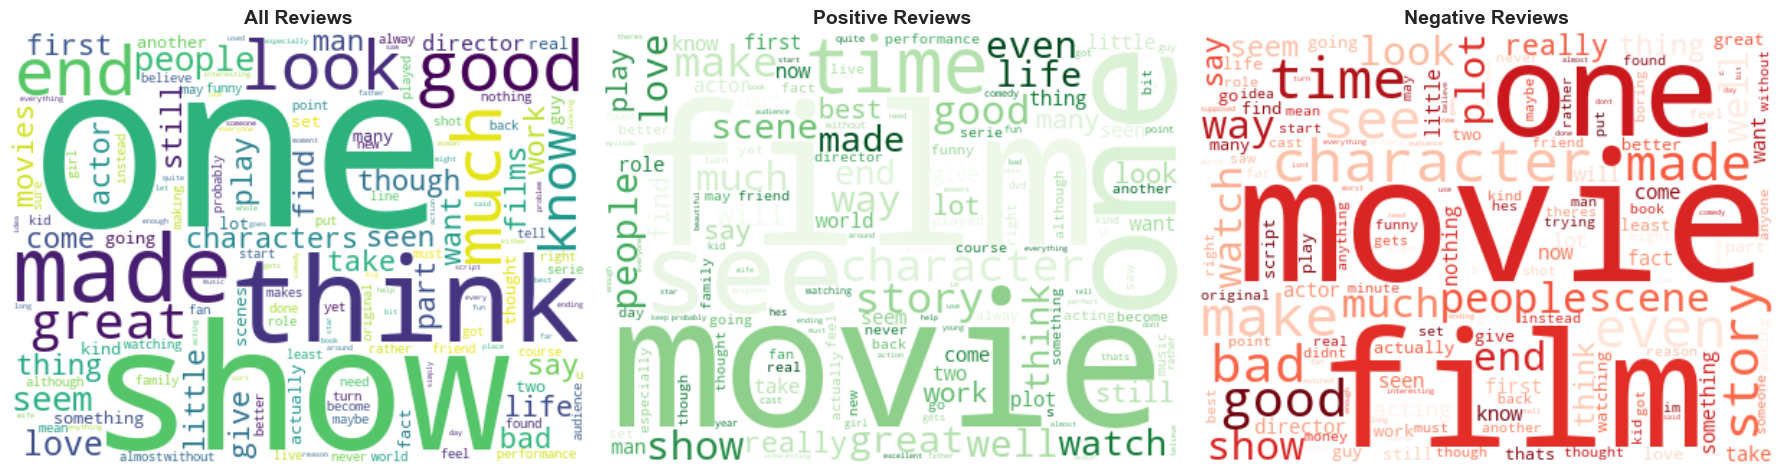

In [ ]:
# Generate word clouds
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# All reviews
all_text = ' '.join(df['review'].values)
all_text = re.sub(r'<br />', ' ', all_text.lower())
all_text = re.sub(r'[^a-zA-Z\s]', '', all_text)
wc_all = WordCloud(width=400, height=300, background_color='white', max_words=150).generate(all_text)
axes[0].imshow(wc_all, interpolation='bilinear')
axes[0].set_title('All Reviews', fontsize=14, fontweight='bold')
axes[0].axis('off')

# Positive reviews
pos_text = ' '.join(pos_reviews['review'].values)
pos_text = re.sub(r'<br />', ' ', pos_text.lower())
pos_text = re.sub(r'[^a-zA-Z\s]', '', pos_text)
wc_pos = WordCloud(width=400, height=300, background_color='white', colormap='Greens', max_words=150).generate(pos_text)
axes[1].imshow(wc_pos, interpolation='bilinear')
axes[1].set_title('Positive Reviews', fontsize=14, fontweight='bold')
axes[1].axis('off')

# Negative reviews
neg_text = ' '.join(neg_reviews['review'].values)
neg_text = re.sub(r'<br />', ' ', neg_text.lower())
neg_text = re.sub(r'[^a-zA-Z\s]', '', neg_text)
wc_neg = WordCloud(width=400, height=300, background_color='white', colormap='Reds', max_words=150).generate(neg_text)
axes[2].imshow(wc_neg, interpolation='bilinear')
axes[2].set_title('Negative Reviews', fontsize=14, fontweight='bold')
axes[2].axis('off')

plt.tight_layout()
plt.show()

## **Calculate Word Sentiment Polarity Score**

Analyzes each word's association with positive or negative sentiment based on review labels.

 Example: Word "excellent" appears in 500 reviews
 480 of those reviews are positive (1), 20 are negative (0)
 Score = (480×1 + 20×0) / 500 = 0.96 (96% positive)

In [ ]:
from collections import defaultdict  # Creates dictionary with default values

def calculate_word_sentiment_score(df, top_n=30):
    word_sentiment = defaultdict(list)  # Store sentiment scores for each word
    
    for idx, row in df.iterrows():  # Loop through each review
        sentiment = 1 if row['sentiment'] == 'positive' else 0  # Convert to binary (1=positive, 0=negative)
        words = set(re.sub(r'[^a-zA-Z\s]', '', row['review'].lower()).split())  # Clean and get unique words
        
        for word in words:
            if len(word) > 3:  # Only consider words longer than 3 letters
                word_sentiment[word].append(sentiment)  # Add sentiment to word's list
    
    word_scores = {}
    for word, scores in word_sentiment.items():
        if len(scores) > 100:  # Only words appearing in 100+ reviews
            word_scores[word] = np.mean(scores)  # Average sentiment (0-1 scale)
    
    sorted_words = sorted(word_scores.items(), key=lambda x: x[1], reverse=True)  # Sort by sentiment score
    
    print(" Most POSITIVE-associated words (appearing >100 times):")
    for word, score in sorted_words[:15]:  # Top 15 most positive
        print(f"   {word}: {score:.3f} ({(score*100):.1f}% positive)")
    
    print("\n Most NEGATIVE-associated words (appearing >100 times):")
    for word, score in sorted_words[-15:][::-1]:  # Bottom 15 most negative
        print(f"   {word}: {score:.3f} ({(score*100):.1f}% positive)")

calculate_word_sentiment_score(df)  

 Most POSITIVE-associated words (appearing >100 times):
   matthau: 0.922 (92.2% positive)
   flawless: 0.905 (90.5% positive)
   perfection: 0.894 (89.4% positive)
   understated: 0.887 (88.7% positive)
   superbly: 0.886 (88.6% positive)
   wonderfully: 0.882 (88.2% positive)
   mustsee: 0.881 (88.1% positive)
   heartbreaking: 0.872 (87.2% positive)
   captures: 0.870 (87.0% positive)
   unforgettable: 0.869 (86.9% positive)
   delightfully: 0.865 (86.5% positive)
   refreshing: 0.864 (86.4% positive)
   heartwarming: 0.864 (86.4% positive)
   beautifully: 0.863 (86.3% positive)
   timeless: 0.863 (86.3% positive)

 Most NEGATIVE-associated words (appearing >100 times):
   stinker: 0.041 (4.1% positive)
   mstk: 0.055 (5.5% positive)
   unwatchable: 0.060 (6.0% positive)
   godawful: 0.067 (6.7% positive)
   waste: 0.068 (6.8% positive)
   incoherent: 0.077 (7.7% positive)
   unfunny: 0.083 (8.3% positive)
   wasting: 0.085 (8.5% positive)
   camcorder: 0.088 (8.8% positive)
   driv

## **Text Cleaning Function**

Removes HTML tags, punctuation, numbers, and stopwords to prepare text for analysis.

In [ ]:
def clean_text(text, remove_stopwords=True):
    # Step 1: Remove HTML tags
    text = re.sub(r'<[^>]+>', ' ', text)     # Remove any HTML tags like <br>
    text = re.sub(r'<br\s*/?>', ' ', text)   # Specifically target <br /> tags
    
    # Step 2: Normalize text
    text = text.lower()                       # Convert everything to lowercase
    text = re.sub(r'[^\w\s]', ' ', text)     # Remove punctuation (!,?,., etc.)
    text = re.sub(r'\d+', ' ', text)         # Remove numbers (123, 456)
    text = re.sub(r'[^a-zA-Z\s]', ' ', text) # Keep only letters and spaces
    text = re.sub(r'\s+', ' ', text)         # Remove extra spaces
    text = text.strip()                       # Trim whitespace from ends
    
    # Step 3: Remove stopwords (optional)
    if remove_stopwords:
        stop_words = set(stopwords.words('english'))  # Common words: 'the', 'and', 'a'
        movie_stopwords = {'movie', 'film', 'scene', 'character', 'plot',   # Movie-specific common words
                          'story', 'watch', 'see', 'make', 'time', 'way',
                          'really', 'get', 'even', 'also', 'well', 'go'}
        stop_words.update(movie_stopwords)            # Combine both stopword sets
        
        words = text.split()                           # Split into individual words
        words = [word for word in words if word not in stop_words]  # Remove stopwords
        text = ' '.join(words)                         # Join words back together
    
    return text  # Return cleaned text

In [ ]:
print("Sample before cleaning:\n")
print(df["review"].iloc[1])
df['review'] = df['review'].apply(lambda x: clean_text(x, remove_stopwords=True))
print("\nSample before cleaning:\n")
print(df["review"].iloc[1])

Sample before cleaning:

A wonderful little production. <br /><br />The filming technique is very unassuming- very old-time-BBC fashion and gives a comforting, and sometimes discomforting, sense of realism to the entire piece. <br /><br />The actors are extremely well chosen- Michael Sheen not only "has got all the polari" but he has all the voices down pat too! You can truly see the seamless editing guided by the references to Williams' diary entries, not only is it well worth the watching but it is a terrificly written and performed piece. A masterful production about one of the great master's of comedy and his life. <br /><br />The realism really comes home with the little things: the fantasy of the guard which, rather than use the traditional 'dream' techniques remains solid then disappears. It plays on our knowledge and our senses, particularly with the scenes concerning Orton and Halliwell and the sets (particularly of their flat with Halliwell's murals decorating every surface) 

In [ ]:
def get_top_words_after_cleaning(df, sentiment_label, n=20):
    """Get top words from cleaned reviews by sentiment"""
    filtered_df = df[df['sentiment'] == sentiment_label]  # Filter positive or negative reviews
    all_text = ' '.join(filtered_df['review'].values)      # Combine all reviews into one string
    words = all_text.split()                               # Split into individual words
    word_counts = Counter(words)                           # Count frequency of each word
    return word_counts.most_common(n)                      # Return top n most frequent words

top_pos_cleaned = get_top_words_after_cleaning(df, 'positive', 20)  
top_neg_cleaned = get_top_words_after_cleaning(df, 'negative', 20)  

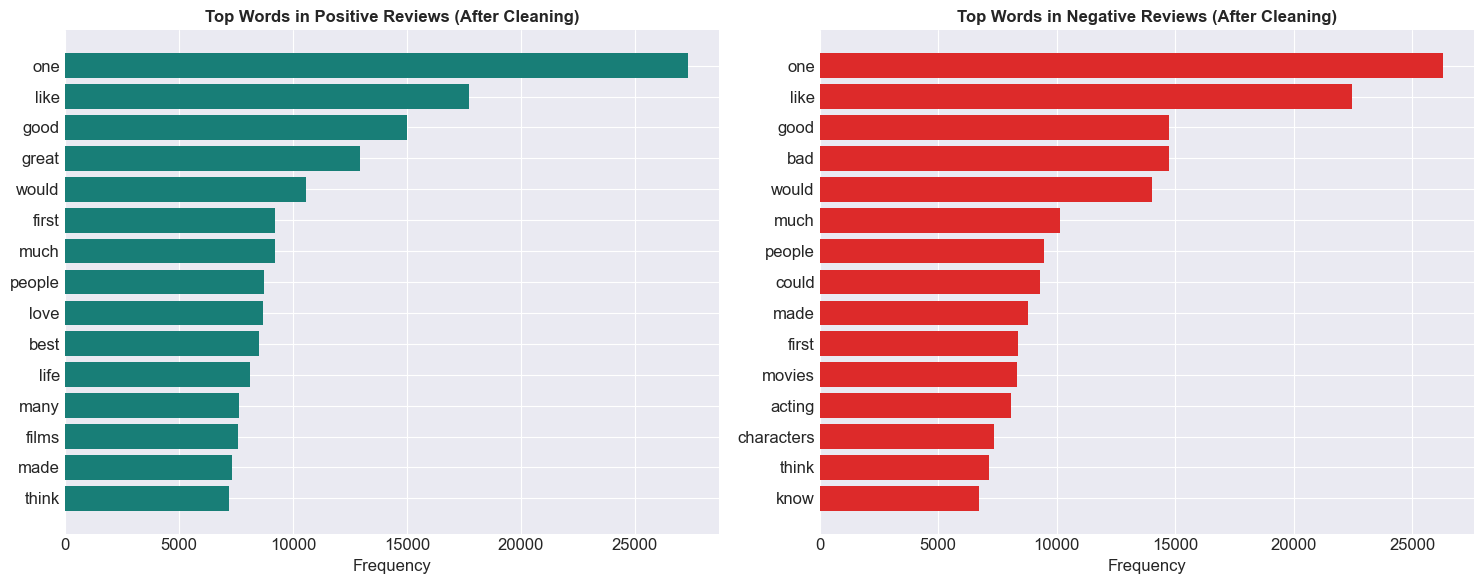

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

words_pos, counts_pos = zip(*top_pos_cleaned[:15])
axes[0].barh(words_pos, counts_pos, color='#187e77')
axes[0].set_title('Top Words in Positive Reviews (After Cleaning)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Frequency')
axes[0].invert_yaxis()

words_neg, counts_neg = zip(*top_neg_cleaned[:15])
axes[1].barh(words_neg, counts_neg, color='#dd2a2a')
axes[1].set_title('Top Words in Negative Reviews (After Cleaning)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Frequency')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

In [ ]:
df['label'] = df['sentiment'].apply(lambda x: 1 if x == 'positive' else 0)

X = df['review'].values
y = df['label'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## **TF-IDF Vectorization**

Converts text reviews into numerical feature vectors based on word importance.

In [ ]:
tfidf = TfidfVectorizer(
    max_features=35000,          
    ngram_range=(1, 3),          # Use single words, pairs, and triplets (1-3 words)
    stop_words='english',        
    min_df=2,                    # Ignore words that appear in less than 2 documents
    max_df=0.7,                  # Ignore words that appear in more than 70% of documents
    sublinear_tf=True,           
    use_idf=True,                # Penalize words that appear in many documents
    smooth_idf=True,             # Add 1 to document frequency to avoid division by zero
    norm='l2'                    # Normalize vectors to unit length (Euclidean norm)
)

X_train_tfidf = tfidf.fit_transform(X_train)  # Learn vocabulary + transform training data
X_test_tfidf = tfidf.transform(X_test)        # Transform test data using same vocabulary

## **Logistic Regression Model Training**

Trains a logistic regression classifier on TF-IDF features to predict sentiment.

In [ ]:
log_reg = LogisticRegression(
    C=1.5,                    # Inverse regularization strength (lower = stronger regularization)
    max_iter=1000,            
    random_state=42,          
    class_weight='balanced'   # Automatically adjust weights for imbalanced classes
)

log_reg.fit(X_train_tfidf, y_train)  # Train model on TF-IDF features with labels

LogisticRegression(C=1.5, class_weight='balanced', max_iter=1000,
                   random_state=42)

In [ ]:
y_pred = log_reg.predict(X_test_tfidf)
y_pred_proba = log_reg.predict_proba(X_test_tfidf)[:, 1]

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

In [ ]:
print(f"   Accuracy: ({accuracy*100:.2f}%)")
print(f"   Precision:({precision*100:.2f}%)")
print(f"   Recall:  ({recall*100:.2f}%)")
print(f"   F1-Score: ({f1*100:.2f}%)")

   Accuracy: (90.23%)
   Precision:(89.23%)
   Recall:  (91.50%)
   F1-Score: (90.35%)


In [ ]:
print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))

              precision    recall  f1-score   support

    Negative       0.91      0.89      0.90      5000
    Positive       0.89      0.92      0.90      5000

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000



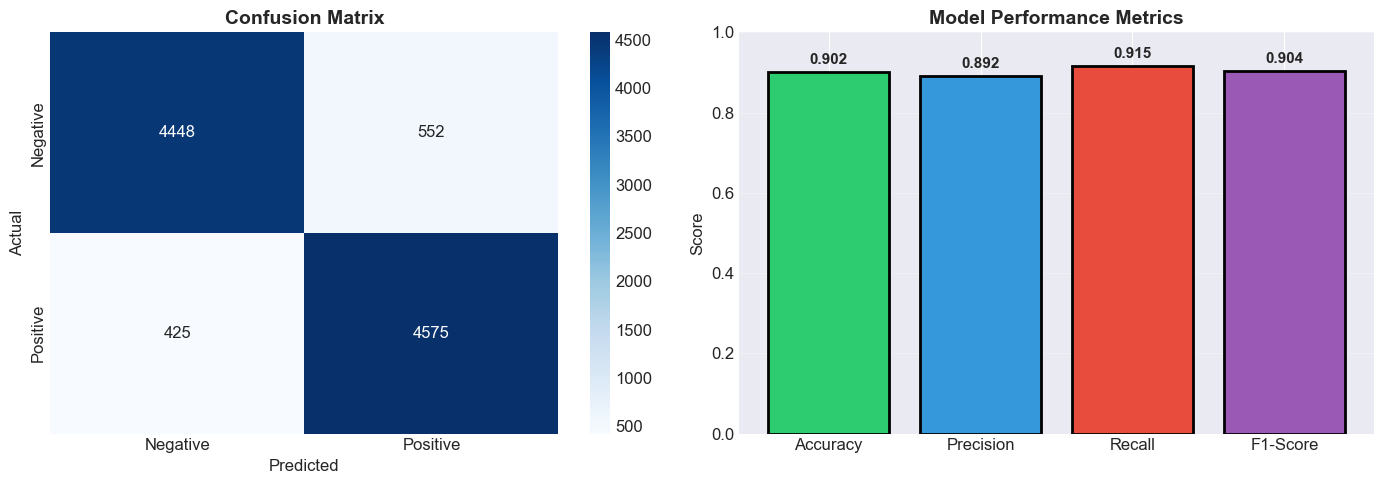

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'],
            ax=axes[0])
axes[0].set_title('Confusion Matrix', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
values = [accuracy, precision, recall, f1]
colors = ['#2ecc71', '#3498db', '#e74c3c', '#9b59b6']

bars = axes[1].bar(metrics, values, color=colors, edgecolor='black', linewidth=2)
axes[1].set_ylim(0, 1)
axes[1].set_title('Model Performance Metrics', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Score')
axes[1].grid(True, alpha=0.3, axis='y')

for bar, val in zip(bars, values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
                 f'{val:.3f}', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

## **Top Sentiment Words Visualization**

Extracts and plots the most influential words for positive and negative sentiment based on model coefficients.

#### **HOW IT WORKS:**
 When the model sees a word with a high positive score, it pushes prediction toward "positive"
 When it sees a word with a high negative score, it pushes prediction toward "negative"
 The model adds up all word scores to make final decision

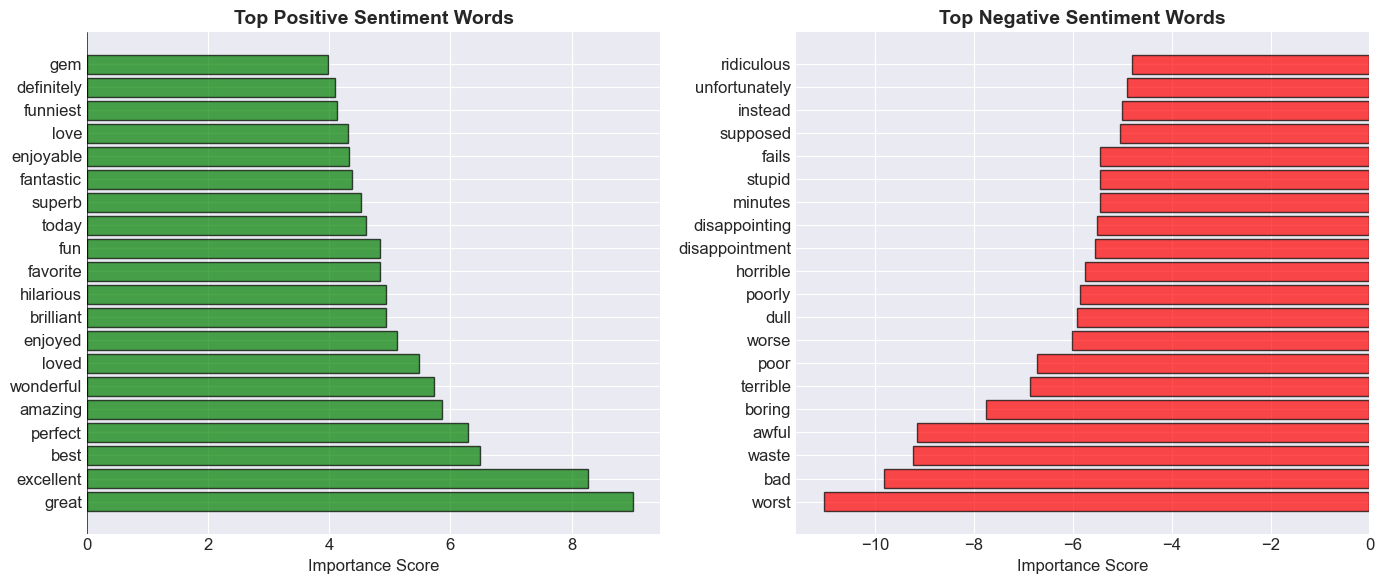

In [ ]:
feature_names = tfidf.get_feature_names_out()     # Get all feature (word) names
coefficients = log_reg.coef_[0]                   # Get importance scores for each word

top_positive_idx = np.argsort(coefficients)[-20:][::-1]  # Indices of 20 most positive words
top_negative_idx = np.argsort(coefficients)[:20]         # Indices of 20 most negative words

fig, axes = plt.subplots(1, 2, figsize=(14, 6))     # Create side-by-side plots

# Positive words plot
pos_words = [feature_names[i] for i in top_positive_idx]        # Word names
pos_coef = [coefficients[i] for i in top_positive_idx]          # Importance scores
axes[0].barh(pos_words, pos_coef, color='green', alpha=0.7, edgecolor='black')  # Horizontal bar chart
axes[0].set_title('Top Positive Sentiment Words', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Importance Score')
axes[0].axvline(x=0, color='black', linestyle='-', linewidth=0.5)  # Zero line

# Negative words plot
neg_words = [feature_names[i] for i in top_negative_idx]        # Word names
neg_coef = [coefficients[i] for i in top_negative_idx]          # Importance scores
axes[1].barh(neg_words, neg_coef, color='red', alpha=0.7, edgecolor='black')
axes[1].set_title('Top Negative Sentiment Words', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Importance Score')
axes[1].axvline(x=0, color='black', linestyle='-', linewidth=0.5)

plt.tight_layout()                                     
plt.show()                                            

In [ ]:
confidence = np.where(y_pred == 1, y_pred_proba, 1 - y_pred_proba)

correct_pred = y_pred == y_test
confident_correct = confidence[correct_pred]
confident_incorrect = confidence[~correct_pred]

print(f"Correct predictions avg confidence: {confident_correct.mean():.3f}")
print(f"Incorrect predictions avg confidence: {confident_incorrect.mean():.3f}")

Correct predictions avg confidence: 0.856
Incorrect predictions avg confidence: 0.659
